# XGBoost

In [1]:
from datetime import datetime
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA. Se utilizan tanto las **características TF-IDF** (vectores de alta dimensionalidad generados por `TfidfVectorizer`) como las **características adicionales** (atributos lingüísticos y estructurales extraídos durante el EDA: presencia de links, indicadores de urgencia, densidad de pronombres, verbos imperativos, categoría de cantidad de palabras, etc.).

In [2]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

## Preprocesamiento y Transformación

Se aplica el mismo pipeline de preprocesamiento utilizado en los modelos anteriores (Regresión Logística y KNN):

* **StandardScaler (con `with_mean=False`):** Aplicado sobre la matriz TF-IDF y sobre los atributos numéricos adicionales, asegurando que todas las variables compartan una escala común sin alterar la dispersión de la matriz TF-IDF.
* **OneHotEncoder:** Aplicado sobre la variable categórica `words_count_cat`, eliminando la primera categoría (`drop='first'`) para evitar multicolinealidad.
* **passthrough:** Preserva las variables binarias preexistentes (`has_link`, `domain_dot_high`, `has_suspicious_tags`).

In [3]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler_num = StandardScaler(with_mean=False)
scaler_tfidf = StandardScaler(with_mean=False)

tf = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link', 'domain_dot_high', 'has_suspicious_tags']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler_num, ['imperative_verbs_count', 'pronoun_density', 'urgency_markers_count'])
],
remainder='drop')

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

X_extra_train = tf.fit_transform(X_extra_train)
X_extra_test = tf.transform(X_extra_test)

X_train = hstack([X_train, X_extra_train])
X_test = hstack([X_test, X_extra_test])

## Modelo: XGBClassifier

Se configura el clasificador XGBoost con los siguientes hiperparámetros:

* `objective='binary:logistic'`: Clasificación binaria con salida probabilística.
* `eval_metric='logloss'`: Función de pérdida logarítmica para evaluación.
* `n_estimators=200`: Número de árbole.
* `max_depth=6`: Profundidad máxima de cada árbol individual.
* `learning_rate=0.05`: Tasa de aprendizaje.
* `subsample=0.9`: Fracción de muestras utilizadas por cada árbol.
* `reg_lambda=1`: Regularización L2 (Ridge).

In [4]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    reg_lambda=1
)

start_train = datetime.now()
xgb_model.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = xgb_model.predict(X_test)
predict_duration = datetime.now() - start_pred

## Evaluación del Modelo

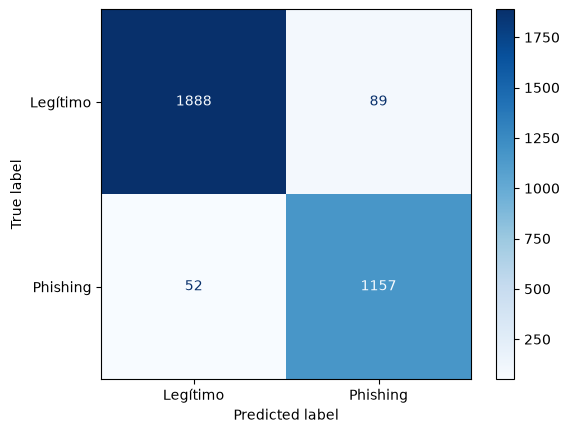

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [6]:
cm_xgb = confusion_matrix(y_test, y_pred)
P = cm_xgb[1, :].sum()
N = cm_xgb[0, :].sum()
TP = cm_xgb[1, 1]
TN = cm_xgb[0, 0]

TPR_xgb = TP / P
TNR_xgb = TN / N
balanced_accuracy_xgb = (TPR_xgb + TNR_xgb) / 2

precision_xgb = precision_score(y_test, y_pred, zero_division=0)
recall_xgb = recall_score(y_test, y_pred, zero_division=0)
f1_xgb = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_xgb:.4f}")
print(f"Precisión:               {precision_xgb:.4f}")
print(f"Sensibilidad (Recall):   {TPR_xgb:.4f}")
print(f"F1-score:                {f1_xgb:.4f}")
print(f"Especificidad:           {TNR_xgb:.4f}")
print(f"Recuperación (Recall):   {recall_xgb:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9560
Precisión:               0.9286
Sensibilidad (Recall):   0.9570
F1-score:                0.9426
Especificidad:           0.9550
Recuperación (Recall):   0.9570
Tiempo de entrenamiento: 0:00:40.480477
Tiempo de predicción:    0:00:00.017553


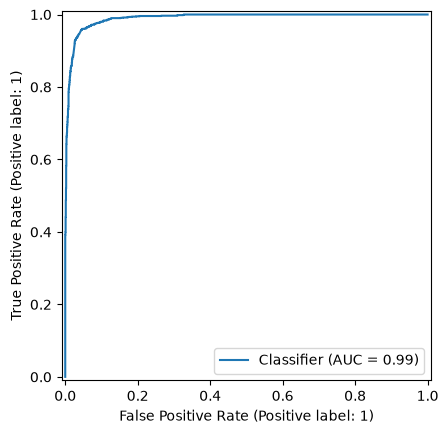

In [7]:
y_scores = xgb_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Los resultados son sobresalientes. La alta sensibilidad (0.95) indica que el modelo detecta correctamente la gran mayoría de correos phishing, mientras que la precisión (0.92) y especificidad (0.95) aseguran una tasa baja de falsos positivos. La curva ROC es consistente con estos valores.

## Validación Cruzada

Dado que los resultados son significativamente superiores a los de los modelos previos, se realiza una validación cruzada (10-fold) sobre el conjunto de entrenamiento para descartar sobreajuste.

In [8]:
cv_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    reg_lambda=1
)

scores = cross_val_predict(cv_xgb_model, X_train, y_train, cv=10, method='predict_proba', n_jobs=-1)[:, 1]

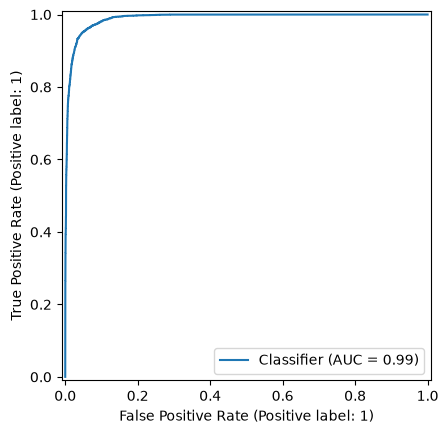

In [9]:
RocCurveDisplay.from_predictions(y_train, scores)

In [10]:
print(f"AUC: {roc_auc_score(y_train, scores):.4f}")

AUC: 0.9898


Se obtiene un **AUC de 0.9898**, lo que confirma que el rendimiento reportado sobre el conjunto de prueba es representativo y generaliza correctamente.

## Análisis de Resultados y Conclusiones

El modelo XGBoost alcanza el mejor rendimiento de todos los modelos evaluados hasta el momento en el proyecto, con una exactitud balanceada de 0.95 y un AUC de 0.9898 en validación cruzada. Esto se debe a que el gradient boosting combina la capacidad de los árboles de decisión para capturar interacciones no lineales entre features con el ensamblado secuencial que reduce el sesgo de manera iterativa.

Los hiperparámetros elegidos (profundidad moderada de 6, tasa de aprendizaje baja de 0.05, 200 árboles) equilibran capacidad de ajuste y generalización. La regularización L2 (`reg_lambda=1`) y el submuestreo (`subsample=0.9`) contribuyen a mitigar el sobreajuste, como lo confirma la validación cruzada.

En cuanto a tiempos, el entrenamiento (~40s) es considerablemente mayor que el de los modelos lineales (Naive Bayes, Regresión Logística), pero sigue siendo razonable. El tiempo de predicción (~0.018s) es prácticamente instantáneo, lo que lo hace viable para despliegues en producción.

XGBoost representa el punto más alto de rendimiento en la comparativa de modelos desarrollada a lo largo de las notebooks del proyecto, consolidándose como la mejor opción para el problema de clasificación de correos phishing con las features disponibles.